In [1]:
import sys
sys.path.append('../../../Share')
import config, baseline, Target, Model

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


from collections import Counter

def balance_data(X, y):
    # Count samples per class
    class_counts = Counter(y)
    min_count = min(class_counts.values())  # target: balance all to minority count

    indices_list = []

    for label in sorted(class_counts.keys()):
        label_indices = np.where(y == label)[0]
        selected_indices = np.random.choice(label_indices, size=min_count, replace=False)
        indices_list.extend(selected_indices)

    # Shuffle all selected indices
    balanced_indices = np.random.permutation(indices_list)

    # Subset the data
    X_balanced = X[balanced_indices]
    y_balanced = y[balanced_indices]

    return X_balanced, y_balanced

In [2]:
SUBJECT = "Minjeong"
baseline_K_val = [i for i in range(len(config.dataset_sub_M))]

ACC_lst = []
for i, K in enumerate(baseline_K_val[1:-1]):
    trainer = baseline.ModelTrainer(config, subject=f"{SUBJECT}")
    X_train, y_train, _, _ = trainer.return_until_K_data(K, train_ratio=1)
    X_train, y_train = balance_data(X_train, y_train)

    X_test, y_test, _, _ = trainer.return_K_th_data_only(K+1, train_ratio=1)
    X_test, y_test = balance_data(X_test, y_test)

    model = Model.Original_model(X_train.shape[1:], num_class=6)

    #print(pd.Series(y_test).value_counts())

    history, _ = Model.Train_model_without_test(model, X_train, y_train, set_epoch=100, set_batch_size=128, Model_name='', set_verbose=False, save_model_set=False)
    acc = model.evaluate(X_test, y_test, verbose=0)[1]
    ACC_lst.append(acc)
    print(ACC_lst, f"{i}/{len(baseline_K_val)}\n\n")
    pd.DataFrame(history.history).to_csv(f'./Result/{SUBJECT}/train_with_{K}_test_with_next_session.csv', index=False)


Dataset 1/18 - Session Exp_2025-08-01-v1/E9AD0E7DCC2B/
Returning K-th session data: Exp_2025-08-02-v1/E9AD0E7DCC2B/
Start Training (total epochs: 100)...
[0.5248538255691528] 0/18


Dataset 1/18 - Session Exp_2025-08-01-v1/E9AD0E7DCC2B/
Dataset 2/18 - Session Exp_2025-08-01-v2/E9AD0E7DCC2B/
Returning K-th session data: Exp_2025-08-02-v2/E9AD0E7DCC2B/
Start Training (total epochs: 100)...
[0.5248538255691528, 0.5611110925674438] 1/18


Dataset 1/18 - Session Exp_2025-08-01-v1/E9AD0E7DCC2B/
Dataset 2/18 - Session Exp_2025-08-01-v2/E9AD0E7DCC2B/
Dataset 3/18 - Session Exp_2025-08-02-v1/E9AD0E7DCC2B/
Returning K-th session data: Exp_2025-08-09-v1/E9AD0E7DCC2B/
Start Training (total epochs: 100)...
[0.5248538255691528, 0.5611110925674438, 0.5962121486663818] 2/18


Dataset 1/18 - Session Exp_2025-08-01-v1/E9AD0E7DCC2B/
Dataset 2/18 - Session Exp_2025-08-01-v2/E9AD0E7DCC2B/
Dataset 3/18 - Session Exp_2025-08-02-v1/E9AD0E7DCC2B/
Dataset 4/18 - Session Exp_2025-08-02-v2/E9AD0E7DCC2B/
Returning

In [3]:
ACC_lst_target = []
for i, K in enumerate(baseline_K_val[1:-1]):
    trainer = baseline.ModelTrainer(config, subject=f"{SUBJECT}")
    X_train, y_train, X_test, y_test = trainer.return_K_th_data_only(K, train_ratio=0.7)
    X_train, y_train = balance_data(X_train, y_train)
    X_test, y_test = balance_data(X_test, y_test)

    model = Model.Original_model(X_train.shape[1:], num_class=6)

    history, _ = Model.Train_model_without_test(model, X_train, y_train, set_epoch=100, set_batch_size=128, Model_name='', set_verbose=False, save_model_set=False)
    acc = model.evaluate(X_test, y_test, verbose=0)[1]
    ACC_lst_target.append(acc)
    print(ACC_lst_target, f"{i}/{len(baseline_K_val)}\n\n")
    #pd.DataFrame(history.history).to_csv(f'./Result/{SUBJECT}/train_with_{K}_test_with_next_session.csv', index=False)


Returning K-th session data: Exp_2025-08-01-v2/E9AD0E7DCC2B/
Start Training (total epochs: 100)...
[0.7418699264526367] 0/18


Returning K-th session data: Exp_2025-08-02-v1/E9AD0E7DCC2B/
Start Training (total epochs: 100)...
[0.7418699264526367, 0.7107843160629272] 1/18


Returning K-th session data: Exp_2025-08-02-v2/E9AD0E7DCC2B/
Start Training (total epochs: 100)...
[0.7418699264526367, 0.7107843160629272, 0.5416666865348816] 2/18


Returning K-th session data: Exp_2025-08-09-v1/E9AD0E7DCC2B/
Start Training (total epochs: 100)...
[0.7418699264526367, 0.7107843160629272, 0.5416666865348816, 0.4833333194255829] 3/18


Returning K-th session data: Exp_2025-08-09-v2/E9AD0E7DCC2B/
Start Training (total epochs: 100)...
[0.7418699264526367, 0.7107843160629272, 0.5416666865348816, 0.4833333194255829, 0.7083333134651184] 4/18


Returning K-th session data: Exp_2025-08-10-v1/E9AD0E7DCC2B/
Start Training (total epochs: 100)...
[0.7418699264526367, 0.7107843160629272, 0.5416666865348816, 0.483

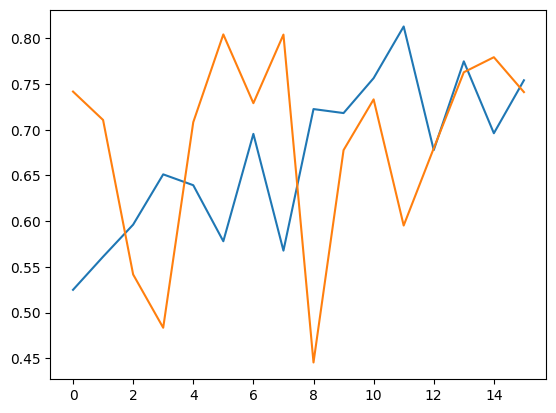

In [4]:
plt.plot(ACC_lst)
plt.plot(ACC_lst_target)
plt.show()

Dataset 1/18 - Session Exp_2025-08-01-v1/E9AD0E7DCC2B/
Dataset 2/18 - Session Exp_2025-08-01-v2/E9AD0E7DCC2B/
Dataset 3/18 - Session Exp_2025-08-02-v1/E9AD0E7DCC2B/
Dataset 4/18 - Session Exp_2025-08-02-v2/E9AD0E7DCC2B/
Dataset 5/18 - Session Exp_2025-08-09-v1/E9AD0E7DCC2B/
Dataset 6/18 - Session Exp_2025-08-09-v2/E9AD0E7DCC2B/
Dataset 7/18 - Session Exp_2025-08-10-v1/E9AD0E7DCC2B/
Dataset 8/18 - Session Exp_2025-08-10-v2/E9AD0E7DCC2B/
Dataset 9/18 - Session Exp_2025-08-11-v1/E9AD0E7DCC2B/
Dataset 10/18 - Session Exp_2025-08-11-v2/E9AD0E7DCC2B/
Dataset 11/18 - Session Exp_2025-08-12-v1/E9AD0E7DCC2B/
Dataset 12/18 - Session Exp_2025-08-12-v2/E9AD0E7DCC2B/
Dataset 13/18 - Session Exp_2025-08-13-v1/E9AD0E7DCC2B/
Dataset 14/18 - Session Exp_2025-08-13-v2/E9AD0E7DCC2B/
Dataset 15/18 - Session Exp_2025-08-14-v1/E9AD0E7DCC2B/
Dataset 16/18 - Session Exp_2025-08-14-v2/E9AD0E7DCC2B/
Returning K-th session data: Exp_2025-08-15-v2/E9AD0E7DCC2B/
Start Training (total epochs: 100)...
Maximum traini

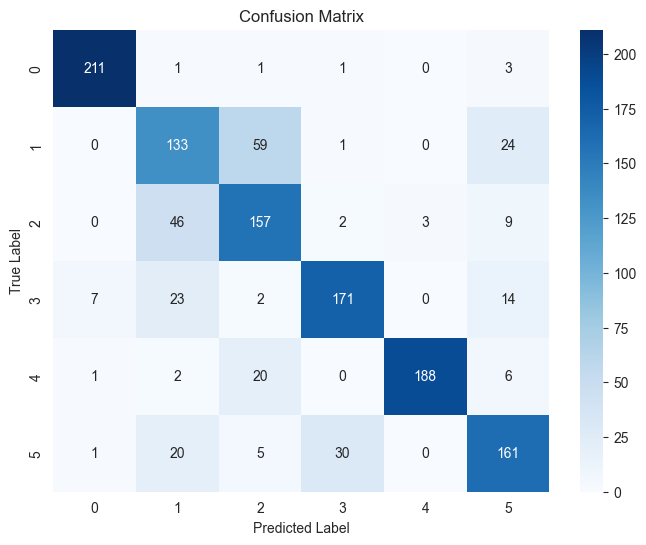

In [2]:
baseline_K_val = [i for i in range(len(config.dataset_sub_M))]
SUBJECT = "Minjeong"

from sklearn.metrics import confusion_matrix
import seaborn as sns
from tensorflow import keras


def heatmap_confusion_matrix(X_test, y_test, model):
    # Predict class labels on the test set
    y_pred_probs = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)  # convert softmax probs to predicted class
    y_true = y_test
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(np.max(y_test)+1), yticklabels=range(np.max(y_test)+1))
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.show()

    return cm


for i, K in enumerate([baseline_K_val[-2]]):
    trainer = baseline.ModelTrainer(config, subject=f"{SUBJECT}")
    X_train, y_train, _, _ = trainer.return_until_K_data(K, train_ratio=1)
    X_train, y_train = balance_data(X_train, y_train)

    X_test, y_test, _, _ = trainer.return_K_th_data_only(K+1, train_ratio=1)
    X_test, y_test = balance_data(X_test, y_test)

    model = Model.Original_model(X_train.shape[1:], num_class=6)

    history, _ =  Model.Train_model(model, X_train, y_train, X_test, y_test, set_epoch=100, set_batch_size=128, Model_name=f'{SUBJECT}_best_model', set_verbose=False, save_model_set=True)

    acc = model.evaluate(X_test, y_test, verbose=0)[1]
    print(acc)

    model_best = keras.models.load_model(f'{SUBJECT}_best_model.keras')

    acc = model_best.evaluate(X_test, y_test, verbose=0)[1]
    print(acc)

    cm = heatmap_confusion_matrix(X_test, y_test, model)

In [3]:
cm.tolist()

[[211, 1, 1, 1, 0, 3],
 [0, 133, 59, 1, 0, 24],
 [0, 46, 157, 2, 3, 9],
 [7, 23, 2, 171, 0, 14],
 [1, 2, 20, 0, 188, 6],
 [1, 20, 5, 30, 0, 161]]

In [6]:
CM=[[211, 1, 1, 1, 0, 3],
 [0, 143, 49, 1, 0, 24],
 [0, 36, 167, 2, 3, 9],
 [7, 23, 2, 171, 0, 14],
 [1, 2, 20, 0, 188, 6],
 [1, 20, 5, 25, 0, 166]]

accuracy = np.trace(CM) / np.sum(CM)
print(f"Overall Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

Overall Accuracy: 0.8034 (80.34%)
